# Problem Definition
Consider a uniform, solid circular cone of mass $M$, base radius $r$, height $h$ and with
its centre of mass coinciding with the origin of axes such that the axis of the cone is
oriented along the $z$-axis and the vertex of the cone points in the positive $z$-direction.

The inertia tensor of such a cone with respect to the principal axes is given by
$$
I = \frac{3}{20}M\begin{bmatrix}
r^2+\frac{1}{4}h^2 & 0 & 0 \\
0 & r+\frac{1}{4}h^2 & 0 \\
0 & 0 & 2r^2
\end{bmatrix}
$$

The cone rotates with angular velocity $\boldsymbol{\omega} = (\omega_{x}, \omega_{y}, \omega_{z})$.
Let’s consider the special case where there are no external torques acting on the cone, $\sum \tau=0$. $\\$
Therefore, using principal axes with an origin at the centre of mass, Euler’s equations become
$$
\dot{\boldsymbol{\omega}}_{x} = -\gamma_{1}\omega_{y}\omega_{z} \\
\dot{\boldsymbol{\omega}}_{y} = -\gamma_{2}\omega_{x}\omega_{z} \\
\dot{\boldsymbol{\omega}}_{z} = -\gamma_{3}\omega_{x}\omega_{y}
$$
where $\gamma_{1}=\frac{I_{3}-I_{2}}{I_{1}}$, $\gamma_{2}=\frac{I_{1}-I_{3}}{I_{2}}$, $\gamma_{3}=\frac{I_{2}-I_{1}}{I_{3}}$ and $I_{i}$ are the principal moments of inertia.
These are a coupled set of ordinary differential equations that describe how the angular speed of rotation evolves with time, $t$, under no external torques.

Knowing the principal moments of inertia $I_{i}$ for a cone and initial conditions for the angular speed, $\boldsymbol{\omega}_{0}$, the Runge-Kutta method can be used to solve these equations numerically.

# Questions

1. For a cone of mass $M = 8 kg$, dimensions $r = 3 m$ and $h = 8 m$, and with initial conditions $\boldsymbol{ω}_{0} = (3, 2, 1)$ rad $s^{−1}$, numerically solve Euler’s equations using your own bespoke fourth-order Runge-Kutta algorithm. Solve Euler’s equations for the case when there are no external torques acting on the cone and where the rotation is about an axis passing through its centre of mass and for a time period of $t ∈ [0, 20] s$.

In [5]:
from typing import Any
import numpy as np
from numpy.typing import NDArray

from simulation import simulate, MagnitudeRecorder
from cone import Cone
import solvers
import graph

ctx = Cone(8,3,8)
initial_angular_momentum = np.array([3,2,1])

def cone_diff_function(w: NDArray[np.number], time_step: float, ctx: Any):
    pom = ctx.principal_moments_of_inertia

    return np.array([
        -(pom[2]-pom[1])/pom[0] * w[1] * w[2],
        -(pom[0]-pom[2])/pom[1] * w[0] * w[2],
        -(pom[1]-pom[0])/pom[2] * w[0] * w[1]
    ])

cone_solver = solvers.RungeKuttaFourthOrder(cone_diff_function)

q1_data = simulate(cone_solver, initial_angular_momentum, ctx, 20, 0.1, "ω", MagnitudeRecorder("angular speed"))

2. From your solutions for Task 1., produce plots of $ω_x(t)$, $ω_y(t)$ and $ω_z(t)$ as a function time, $t$. Also, show the evolution of the angular speed for the toroidal system.

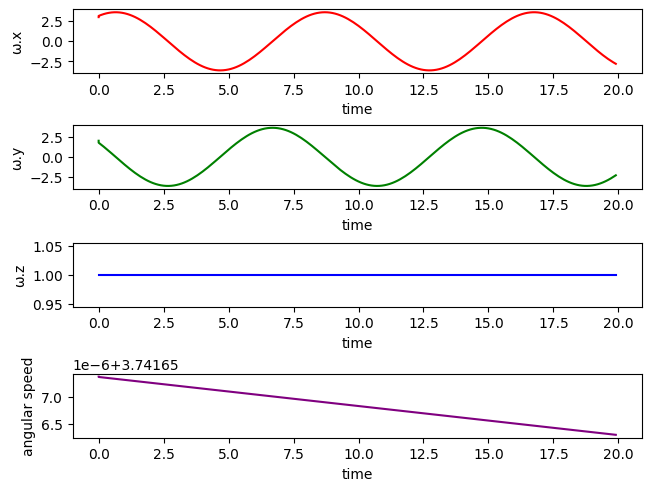

In [6]:
w_plot = graph.multiplot(q1_data)

3. If the centre of mass of the cone is given an initial velocity of $(0, 0, 150) ms^{−1}$ at $t = 0 s$ and its subsequent motion is governed by the force of gravity such that its acceleration is $\boldsymbol{a}_{cm} = (0, 0, −9.8) ms^{−2}$, determine its resulting trajectory for the time period $t ∈ [0, 20] s$. To obtain the trajectory solve Newton’s second law of motion using the semi-implicit Euler method.

In [7]:
from solvers import semi_implicit_euler
from src.numeric_types import Motion

initial_motion = Motion(
    np.array([0,0,0]),
    np.array([0,0,150]),
    np.array([0,0,-9.8])
)

q3_data = simulate(semi_implicit_euler, initial_motion, None, 20, 0.1)

4. From your solutions for Task 3., produce plots of the vertical velocity and vertical displacement as a function of time $t$.

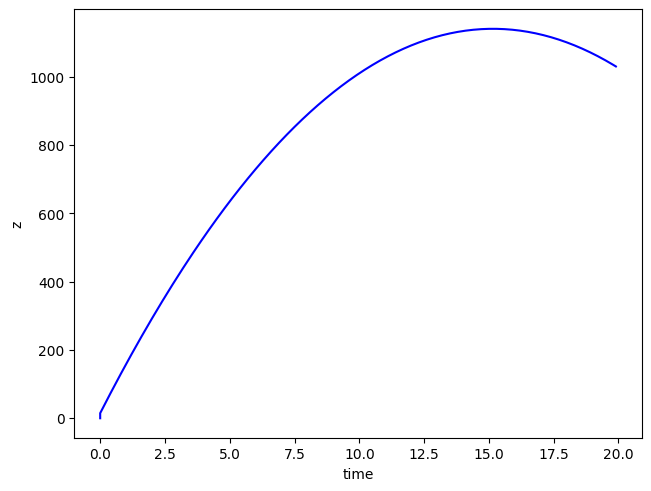

In [ ]:
# ! THIS IS ONLY THE DISPLACEMENT !! WE NEED TO GRAPH THE VELOCITY AS WELL ! #
q3_plot = graph.multiplot(q3_data, y_keys=["z"])

5. The complete motion of the cone will be a combination of its free rotation and its translational motion. Using the $\boldsymbol{ω}$ solution (Task 1.) and the cone trajectory (Task 3.), extend your code to determine the trajectory of the point $P$ that has initial position $(0, 2r/3, 0)$ as a function of time. From your simulation, produce 2D projections on the (i) xy-plane, (ii) xz-plane and (iii) yz-plane of the position of $P$ for all times $t ∈ [0, 20] s$. Your plots will show 2D traces of $P$ in time.